In [58]:
## Import modules
import os, sys
import numpy as np
import geopandas as gpd
import cftime
import gc
import shapely
import json
from ipywidgets import interact, FloatSlider
import ipywidgets as widgets
import matplotlib.pyplot as plt

# Import Plotly for interactive plotting
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.colors as pc
from ipywidgets import interact, IntSlider, Dropdown, VBox, HBox
import ipywidgets as widgets

# Add the directory containing 'cmct' to the Python path
# Navigate three levels up to reach main CmCt dir
cmct_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir, os.pardir, os.pardir))

# Initialising Logger
import logging

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s"
)
logger = logging.getLogger(__name__)

# Import utilities for this comparison
sys.path.insert(0, cmct_dir)
from cmct.time_utils import *
from cmct.calving import *
from cmct.calving_modules.interpolation import *
from cmct.calving_modules.residual_calculation import *
# from cmct.calving_modules.json_to_netcdf import *
# from cmct.shapefile_utils import *

# Force initial garbage collection
gc.collect()


39096

In [59]:
# Reload modules to pick up any changes to imports
import importlib
import cmct.calving
import cmct.calving_modules.residual_calculation
import cmct.calving_modules.plotting_utils
from cmct.calving_modules.plotting_utils import *
from cmct.calving import calculate_basin_statistics, format_basin_stats
from cmct.calving import calculate_basin_statistics

importlib.reload(cmct.calving)
importlib.reload(cmct.calving_modules.residual_calculation)
importlib.reload(cmct.calving_modules.plotting_utils)

# Re-import to ensure functions are available
from cmct.calving import *


In [60]:
# Observation Dataset
# Ice sheet
loc = "GIS"  # 'GIS' or 'AIS'

# Set the observation data dir path
obs_filename = cmct_dir + "/data/calving/observed_icemask_ismip_annual.nc"

# To use aggregation functions for basin
basin_aggregation = True  # IMPORTANT

basin_filename = (
    cmct_dir + "/bin/Calving/GRE_Basins_IMBIE2_v1.3/GRE_Basins_IMBIE2_v1.3.shp"
)

# Set the Model Data dir path
# model_filename = cmct_dir + "/test/calving/ensemble/sftgif_B001_hist.nc"
model_filename = cmct_dir + "/test/calving/sftgif_GIS_JPL_ISSM_historical.nc"

# Set time range for comparison
start_year = 2007
end_year = 2010

# List of basins (ex ["NW", "NE"]) to compare if all -> "all", if none -> False
# If you do not know which basins are in the model, you can put "auto"
# NOTE: Align this list with the basins in the model.
basin_list = "all"

# Output filetype and filename
filetype = "netcdf"  # netcdf or json or None
filename = "calving_comparison"

# Optional Configurations
interpolation_method = "slinear"  # 'nearest', 'linear', 'cubic'
accuracy_calculation_method = "mean"  # 'mean', 'RMS',

colors = {
    "CW": "blue",
    "NE": "red",
    "SE": "green",
    "SW": "orange",
    "NO": "purple",
    "NW": "brown",
}


In [61]:
# Check if observation file exist
if not os.path.exists(obs_filename):
    raise FileNotFoundError(f"Observation file not found: {obs_filename}")

# # Check if model file exist
if not os.path.exists(model_filename):
    raise FileNotFoundError(f"Model file not found: {model_filename}")


if basin_aggregation and not os.path.exists(basin_filename):
    raise FileNotFoundError(f"Basin shapefile not found: {basin_filename}")
    # Load basin shapes

print(basin_filename)
basins, basin_list = load_basins(basin_filename, basin_list)

print(obs_filename)
gsfc = load_gsfc_calving(obs_filename, basins)

print(model_filename)
model_res = load_model_calving(model_filename)


/Users/aditya_pachpande/Documents/GitHub/CmCt/bin/Calving/GRE_Basins_IMBIE2_v1.3/GRE_Basins_IMBIE2_v1.3.shp
/Users/aditya_pachpande/Documents/GitHub/CmCt/data/calving/observed_icemask_ismip_annual.nc
/Users/aditya_pachpande/Documents/GitHub/CmCt/test/calving/sftgif_GIS_JPL_ISSM_historical.nc
/Users/aditya_pachpande/Documents/GitHub/CmCt/test/calving/sftgif_GIS_JPL_ISSM_historical.nc


In [62]:
# Simplifying date data type
gsfc.ds["time"] = standardising_time_var(gsfc.time)
model_res.ds["time"] = standardising_time_var(model_res.time)

# Handelling Time Range
checking_calving_daterange(
    gsfc.time.values, model_res.time.values, start_year, end_year
)


The selected dates 2007 to 2010 are within the overlapping data range.


Choosing a range of x and y 
-

In [63]:
def cell_indice_to_plot(x, y):
    coor_x = ((x-1)* 1000) - 720000
    coor_y = ((y-1)* 1000) - 3450000
    return (coor_x, coor_y)

def upscaled_cell_indice_to_plot(x, y):
    coor_x = ((x-1) * 5000) - 720000
    coor_y = ((y-1) * 5000) - 3450000
    return (coor_x, coor_y)

In [64]:
interpolater = Interpolater(model_res, gsfc)
model_res.ds = interpolater.interpolate()
    # Update the gsfc object with the resampled data
new_gsfc = model_res.ds

# Save the resampled data to a new NetCDF file
# output_netcdf_filename = cmct_dir + '/notebooks/Calving/resampled_calving_obs_data.nc'
# resampled_data.to_netcdf(output_netcdf_filename, mode='w', format='NETCDF4')

2025-07-21 10:59:33,393 - INFO - Input x coordinates: [-720000. -715000. -710000. -705000. -700000. -695000. -690000. -685000.
 -680000. -675000. -670000. -665000. -660000. -655000. -650000. -645000.
 -640000. -635000. -630000. -625000. -620000. -615000. -610000. -605000.
 -600000. -595000. -590000. -585000. -580000. -575000. -570000. -565000.
 -560000. -555000. -550000. -545000. -540000. -535000. -530000. -525000.
 -520000. -515000. -510000. -505000. -500000. -495000. -490000. -485000.
 -480000. -475000. -470000. -465000. -460000. -455000. -450000. -445000.
 -440000. -435000. -430000. -425000. -420000. -415000. -410000. -405000.
 -400000. -395000. -390000. -385000. -380000. -375000. -370000. -365000.
 -360000. -355000. -350000. -345000. -340000. -335000. -330000. -325000.
 -320000. -315000. -310000. -305000. -300000. -295000. -290000. -285000.
 -280000. -275000. -270000. -265000. -260000. -255000. -250000. -245000.
 -240000. -235000. -230000. -225000. -220000. -215000. -210000. -20500

In [65]:
print(new_gsfc)  # Print the attributes of the new_gsfc object

<xarray.Dataset> Size: 2GB
Dimensions:   (y: 2880, x: 1680, nv4: 4, time: 36)
Coordinates:
    lon       (y, x) float64 39MB -56.78 -56.77 -56.75 ... 14.21 14.24 14.27
    lat       (y, x) float64 39MB 58.27 58.28 58.28 58.28 ... 79.74 79.73 79.72
  * time      (time) float64 288B 1.98e+03 1.981e+03 ... 2.014e+03 2.015e+03
  * x         (x) float64 13kB -7.195e+05 -7.185e+05 ... 9.585e+05 9.595e+05
  * y         (y) float64 23kB -3.45e+06 -3.448e+06 ... -5.715e+05 -5.705e+05
Dimensions without coordinates: nv4
Data variables:
    lon_bnds  (y, x, nv4) float64 155MB -56.73 -56.75 -56.83 ... 14.31 14.09
    lat_bnds  (y, x, nv4) float64 155MB 58.26 58.3 58.29 ... 79.71 79.75 79.73
    ice_mask  (time, y, x) float64 1GB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes:
    Conventions:  CF-1.6
    title:        ISMIP6 Projections Greenland model output
    institution:  NASA Jet Propulsion Laboratory, Pasadena, USA
    source:       ISSM
    references:   https://doi.org/10.5194/tc-14-3

In [66]:
# Create 2 subplots side by side to compare the region 
def plot_gsfc_comparison(year=2006, area = 4, new_gsfc=new_gsfc, zoom=1.0, original_gsfc=gsfc):
    """Compare original GSFC vs resampled GSFC in specified coordinate regions"""

    top_left = (1165, 1830)
    top_right = (1312, 1830)
    bottom_left = (1165, 1578)
    bottom_right = (1312, 1578)
        
    if area == 1:
        top_left = (1165, 1830)
        top_right = (1312, 1830)
        bottom_left = (1165, 1578)
        bottom_right = (1312, 1578)

    # UPSCALED
        upscaled_top_left = (233, 366)
        upscaled_top_right = (262, 366)
        upscaled_bottom_left = (233, 316)
        upscaled_bottom_right = (262, 316)
            
    elif area == 2:
        # ORIGINAL
        top_left = (815, 543)
        top_right = (887, 543)
        bottom_left = (815, 435)
        bottom_right = (887, 435)

        # UPSCALED
        upscaled_top_left = (163, 109)
        upscaled_top_right = (178, 109)
        upscaled_bottom_left = (163, 87)
        upscaled_bottom_right = (178, 87)
    
    elif area == 3:
        # ORIGINAL
        top_left       = (643, 381)
        top_right      = (883, 381)
        bottom_left    = (643, 137)
        bottom_right   = (883, 137)

        # UPSCALED
        upscaled_top_left     = (129, 77)
        upscaled_top_right    = (177, 77)
        upscaled_bottom_left  = (129, 28)
        upscaled_bottom_right = (177, 28)
        
    elif area == 4:
        top_left       = (417, 1595)
        top_right      = (515, 1595)
        bottom_left    = (417, 1426)
        bottom_right   = (515, 1426)

        # UPSCALED 5-km grid
        upscaled_top_left     = (84, 319)
        upscaled_top_right    = (103, 319)
        upscaled_bottom_left  = (84, 286)
        upscaled_bottom_right = (103, 286)
        
    elif area == 5:
        # 1-km grid (native resolution)
        top_left       = (288, 2025)
        top_right      = (435, 2025)
        bottom_left    = (288, 1772)
        bottom_right   = (435, 1772)

        # UPSCALED 5-km grid
        upscaled_top_left     = (58, 405)
        upscaled_top_right    = (87, 405)
        upscaled_bottom_left  = (58, 355)
        upscaled_bottom_right = (87, 355)
        
    elif area == 6:
        # Area 6: Same as area 5 but will use zoom parameter
        top_left       = (288, 2025)
        top_right      = (435, 2025)
        bottom_left    = (288, 1772)
        bottom_right   = (435, 1772)

        # UPSCALED 5-km grid
        upscaled_top_left     = (58, 405)
        upscaled_top_right    = (87, 405)
        upscaled_bottom_left  = (58, 355)
        upscaled_bottom_right = (87, 355)

    # Apply zoom if zoom > 1.0
    if zoom > 1.0:
        # Calculate original dimensions
        orig_width = top_right[0] - top_left[0]
        orig_height = top_left[1] - bottom_left[1]
        upscaled_width = upscaled_top_right[0] - upscaled_top_left[0]
        upscaled_height = upscaled_top_left[1] - upscaled_bottom_left[1]
        
        # Calculate new dimensions after zoom
        new_width = int(orig_width / zoom)
        new_height = int(orig_height / zoom)
        new_upscaled_width = int(upscaled_width / zoom)
        new_upscaled_height = int(upscaled_height / zoom)
        
        # Calculate center points
        center_x = (top_left[0] + top_right[0]) // 2
        center_y = (top_left[1] + bottom_left[1]) // 2
        upscaled_center_x = (upscaled_top_left[0] + upscaled_top_right[0]) // 2
        upscaled_center_y = (upscaled_top_left[1] + upscaled_bottom_left[1]) // 2
        
        # Calculate new bounds centered on original region
        half_width = new_width // 2
        half_height = new_height // 2
        upscaled_half_width = new_upscaled_width // 2
        upscaled_half_height = new_upscaled_height // 2
        
        # Update coordinates with zoom
        top_left = (center_x - half_width, center_y + half_height)
        top_right = (center_x + half_width, center_y + half_height)
        bottom_left = (center_x - half_width, center_y - half_height)
        bottom_right = (center_x + half_width, center_y - half_height)
        
        upscaled_top_left = (upscaled_center_x - upscaled_half_width, upscaled_center_y + upscaled_half_height)
        upscaled_top_right = (upscaled_center_x + upscaled_half_width, upscaled_center_y + upscaled_half_height)
        upscaled_bottom_left = (upscaled_center_x - upscaled_half_width, upscaled_center_y - upscaled_half_height)
        upscaled_bottom_right = (upscaled_center_x + upscaled_half_width, upscaled_center_y - upscaled_half_height)

    # Get data for the specified year
    gsfc_data = original_gsfc.ds.sel(year=year).ice_mask
    new_gsfc_data = new_gsfc.sel(time=year).ice_mask

    # Calculate coordinate bounds for original region (using 1km resolution)
    orig_x_min = cell_indice_to_plot(top_left[0], top_left[1])[0]
    orig_x_max = cell_indice_to_plot(top_right[0], top_right[1])[0]
    orig_y_min = cell_indice_to_plot(bottom_left[0], bottom_left[1])[1]
    orig_y_max = cell_indice_to_plot(top_left[0], top_left[1])[1]
    
    # Calculate coordinate bounds for upscaled region (using 5km resolution)
    upsc_x_min = upscaled_cell_indice_to_plot(upscaled_top_left[0], upscaled_top_left[1])[0]
    upsc_x_max = upscaled_cell_indice_to_plot(upscaled_top_right[0], upscaled_top_right[1])[0]
    upsc_y_min = upscaled_cell_indice_to_plot(upscaled_bottom_left[0], upscaled_bottom_left[1])[1]
    upsc_y_max = upscaled_cell_indice_to_plot(upscaled_top_left[0], upscaled_top_left[1])[1]
    
    # Create subplot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))
    
    # Plot 1: Original GSFC data with original coordinates
    gsfc_cropped = gsfc_data.sel(x=slice(orig_x_min, orig_x_max), y=slice(orig_y_min, orig_y_max))
    im1 = ax1.imshow(gsfc_cropped, 
                     extent=[orig_x_min, orig_x_max, orig_y_min, orig_y_max],
                     origin='lower', cmap='viridis', aspect='auto')
    zoom_text = f' (Zoom: {zoom:.1f}x)' if zoom > 1.0 else ''
    ax1.set_title(f'Original GSFC Data (1km){zoom_text}\nYear: {year}')
    ax1.set_xlabel('X coordinate (m)')
    ax1.set_ylabel('Y coordinate (m)')
    
    # Add rectangle showing the exact region
    from matplotlib.patches import Rectangle
    rect1 = Rectangle((orig_x_min, orig_y_min), 
                     orig_x_max - orig_x_min, 
                     orig_y_max - orig_y_min,
                     linewidth=2, edgecolor='red', facecolor='none')
    ax1.add_patch(rect1)
    
    # Plot 2: Resampled GSFC data with upscaled coordinates  
    new_gsfc_cropped = new_gsfc_data.sel(x=slice(upsc_x_min, upsc_x_max), y=slice(upsc_y_min, upsc_y_max))
    im2 = ax2.imshow(new_gsfc_cropped,
                     extent=[upsc_x_min, upsc_x_max, upsc_y_min, upsc_y_max], 
                     origin='lower', cmap='viridis', aspect='auto')
    ax2.set_title(f'Resampled GSFC Data (5km){zoom_text}\nYear: {year}')
    ax2.set_xlabel('X coordinate (m)')
    ax2.set_ylabel('Y coordinate (m)')
    
    # Add rectangle showing the exact upscaled region
    rect2 = Rectangle((upsc_x_min, upsc_y_min),
                     upsc_x_max - upsc_x_min,
                     upsc_y_max - upsc_y_min, 
                     linewidth=2, edgecolor='blue', facecolor='none')
    ax2.add_patch(rect2)
    
    # Add colorbars
    plt.colorbar(im1, ax=ax1, label='Ice Mask Value')
    plt.colorbar(im2, ax=ax2, label='Ice Mask Value')
    
    # Print statistics with zoom info
    if zoom > 1.0:
        print(f"\nZoom Level: {zoom:.1f}x")
        print(f"Original region dimensions: {orig_width}x{orig_height} -> {new_width}x{new_height}")
        print(f"Upscaled region dimensions: {upscaled_width}x{upscaled_height} -> {new_upscaled_width}x{new_upscaled_height}")
    
    plt.tight_layout()
    plt.show()

# Test the function

print("Testing comparison plot...")
# plot_gsfc_comparison(2006)

# Create interactive widget
print("\nCreating interactive widget...")
time_slider = FloatSlider(
    value=start_year,
    min=start_year, 
    max=end_year,
    step=1,
    description='Year:',
    continuous_update=True
)

area_slider = FloatSlider(
    value=3,
    min=1, 
    max=6,
    step=1,
    description='Area:',
    continuous_update=True
)

zoom_slider = FloatSlider(
    value=1.0,
    min=1.0, 
    max=20.0,
    step=0.5,
    description='Zoom:',
    continuous_update=True
)

try:
    interact(plot_gsfc_comparison, year=time_slider, area=area_slider, zoom=zoom_slider)

except Exception as e:
    print(f"Error in plotting: {e}")
    print("Checking data availability...")
#     # Check if the data is available for the specified year
#     # Debug information
#     print(f"gsfc.ds type: {type(gsfc.ds)}")
#     print(f"new_gsfc type: {type(new_gsfc)}")
    
#     if hasattr(gsfc.ds, 'ice_mask'):
#         print(f"gsfc.ds.ice_mask shape: {gsfc.ds.ice_mask.shape}")
#     if hasattr(new_gsfc, 'ice_mask'):
#         print(f"new_gsfc.ice_mask shape: {new_gsfc.ice_mask.shape}")



Testing comparison plot...

Creating interactive widget...
Error in plotting: Invalid selection: value not found
Checking data availability...
Error in plotting: Invalid selection: value not found
Checking data availability...


In [67]:
# import logging.config
# logging.config.dictConfig({
#     'version': 1,
#     'disable_existing_loggers': True,
# })
# for i in ['linear', 'nearest', 'makima', 'pchip', 'cubic', 'lanczos3d']:
#     print(i)
#     new_gsfc = interpolate(model_res, gsfc, i)
#     plot_gsfc_comparison(2006, 3, new_gsfc=new_gsfc[i])

In [68]:
methods = ['nearest', 'linear', 'cubic', 'lanczos3d']
interpolation_results = {}

# Create a target grid that forces interpolation (slightly different resolution)
# Use a 5km grid instead of 1km to force interpolation
original_x = model_res.ds.x.values
original_y = model_res.ds.y.values

# Create target coordinates with 5km spacing (every 5th point)
target_x_coords = original_x[::5]  
target_y_coords = original_y[::5]

print(f"Original grid: {len(original_x)} × {len(original_y)} (1km resolution)")
print(f"Target grid: {len(target_x_coords)} × {len(target_y_coords)} (5km resolution)")

# Create target dataset for interpolation
target_coords = {'x': target_x_coords, 'y': target_y_coords, 'time': gsfc.ds.time}
dummy_data = np.zeros((len(target_coords['time']), len(target_y_coords), len(target_x_coords)))
target_dataset = xr.Dataset({
    'ice_mask': (['time', 'y', 'x'], dummy_data)
}, coords=target_coords)

class TargetGrid:
    def __init__(self, ds):
        self.ds = ds

target_grid = TargetGrid(target_dataset)

for i in methods:
    print(f"\nProcessing {i} method...")
    # Create a new interpolater instance for each method with the method specified in constructor
    interpolater = Interpolater(model_res, target_grid, interpolation_method=i)
    interpolated_ds = interpolater.interpolate()
    interpolation_results[i] = interpolated_ds


2025-07-21 10:59:42,211 - INFO - Input x coordinates: [-719500. -718500. -717500. ...  957500.  958500.  959500.]
2025-07-21 10:59:42,212 - INFO - Input y coordinates: [-3449500. -3448500. -3447500. ...  -572500.  -571500.  -570500.]
2025-07-21 10:59:42,217 - WARNING - Checking coordinate alignment for shape trimming...
2025-07-21 10:59:42,219 - INFO - Cannot align coordinates: X - Different spacing between coordinates, Y - Different spacing between coordinates
2025-07-21 10:59:42,219 - INFO - Coordinate trimming not possible, falling back to interpolation
2025-07-21 10:59:42,212 - INFO - Input y coordinates: [-3449500. -3448500. -3447500. ...  -572500.  -571500.  -570500.]
2025-07-21 10:59:42,217 - WARNING - Checking coordinate alignment for shape trimming...
2025-07-21 10:59:42,219 - INFO - Cannot align coordinates: X - Different spacing between coordinates, Y - Different spacing between coordinates
2025-07-21 10:59:42,219 - INFO - Coordinate trimming not possible, falling back to in

Original grid: 1680 × 2880 (1km resolution)
Target grid: 336 × 576 (5km resolution)

Processing nearest method...


2025-07-21 10:59:47,849 - INFO - Input x coordinates: [-719500. -718500. -717500. ...  957500.  958500.  959500.]
2025-07-21 10:59:47,849 - INFO - Input y coordinates: [-3449500. -3448500. -3447500. ...  -572500.  -571500.  -570500.]
2025-07-21 10:59:47,852 - WARNING - Checking coordinate alignment for shape trimming...
2025-07-21 10:59:47,853 - INFO - Cannot align coordinates: X - Different spacing between coordinates, Y - Different spacing between coordinates
2025-07-21 10:59:47,853 - INFO - Coordinate trimming not possible, falling back to interpolation
2025-07-21 10:59:47,849 - INFO - Input y coordinates: [-3449500. -3448500. -3447500. ...  -572500.  -571500.  -570500.]
2025-07-21 10:59:47,852 - WARNING - Checking coordinate alignment for shape trimming...
2025-07-21 10:59:47,853 - INFO - Cannot align coordinates: X - Different spacing between coordinates, Y - Different spacing between coordinates
2025-07-21 10:59:47,853 - INFO - Coordinate trimming not possible, falling back to in


Processing linear method...


2025-07-21 10:59:54,847 - INFO - Input x coordinates: [-719500. -718500. -717500. ...  957500.  958500.  959500.]
2025-07-21 10:59:54,848 - INFO - Input y coordinates: [-3449500. -3448500. -3447500. ...  -572500.  -571500.  -570500.]
2025-07-21 10:59:54,852 - WARNING - Checking coordinate alignment for shape trimming...
2025-07-21 10:59:54,853 - INFO - Cannot align coordinates: X - Different spacing between coordinates, Y - Different spacing between coordinates
2025-07-21 10:59:54,853 - INFO - Coordinate trimming not possible, falling back to interpolation
2025-07-21 10:59:54,848 - INFO - Input y coordinates: [-3449500. -3448500. -3447500. ...  -572500.  -571500.  -570500.]
2025-07-21 10:59:54,852 - WARNING - Checking coordinate alignment for shape trimming...
2025-07-21 10:59:54,853 - INFO - Cannot align coordinates: X - Different spacing between coordinates, Y - Different spacing between coordinates
2025-07-21 10:59:54,853 - INFO - Coordinate trimming not possible, falling back to in


Processing cubic method...


2025-07-21 11:02:04,544 - INFO - Input x coordinates: [-719500. -718500. -717500. ...  957500.  958500.  959500.]
2025-07-21 11:02:04,545 - INFO - Input y coordinates: [-3449500. -3448500. -3447500. ...  -572500.  -571500.  -570500.]
2025-07-21 11:02:04,548 - WARNING - Checking coordinate alignment for shape trimming...
2025-07-21 11:02:04,549 - INFO - Cannot align coordinates: X - Different spacing between coordinates, Y - Different spacing between coordinates
2025-07-21 11:02:04,549 - INFO - Coordinate trimming not possible, falling back to interpolation
2025-07-21 11:02:04,545 - INFO - Input y coordinates: [-3449500. -3448500. -3447500. ...  -572500.  -571500.  -570500.]
2025-07-21 11:02:04,548 - WARNING - Checking coordinate alignment for shape trimming...
2025-07-21 11:02:04,549 - INFO - Cannot align coordinates: X - Different spacing between coordinates, Y - Different spacing between coordinates
2025-07-21 11:02:04,549 - INFO - Coordinate trimming not possible, falling back to in


Processing lanczos3d method...


Lanczos3d Interpolation Results:

Zoom Level: 10.0x
Original region dimensions: 147x253 -> 14x25
Upscaled region dimensions: 29x50 -> 2x5


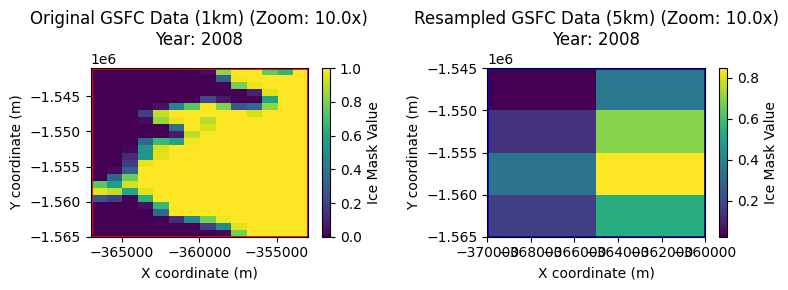

Nearest Interpolation Results:

Zoom Level: 10.0x
Original region dimensions: 147x253 -> 14x25
Upscaled region dimensions: 29x50 -> 2x5


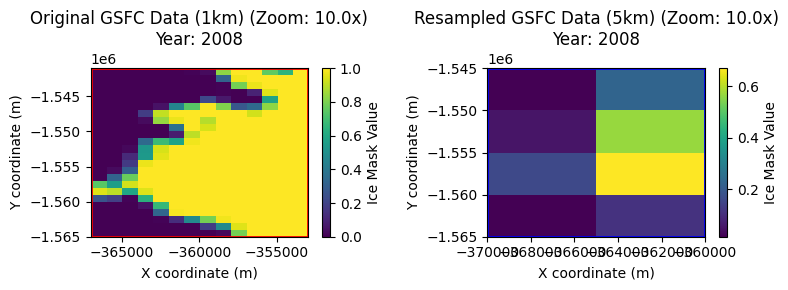

Linear Interpolation Results:

Zoom Level: 10.0x
Original region dimensions: 147x253 -> 14x25
Upscaled region dimensions: 29x50 -> 2x5


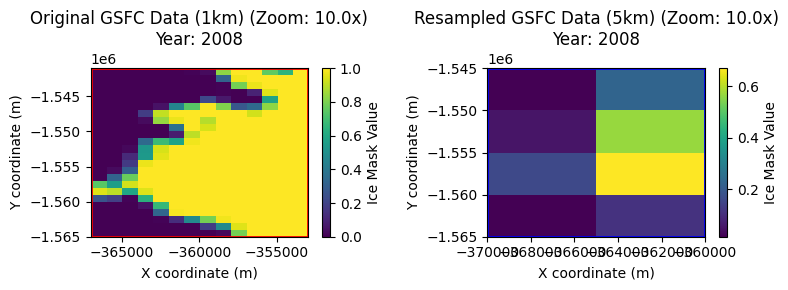

Cubic Interpolation Results:

Zoom Level: 10.0x
Original region dimensions: 147x253 -> 14x25
Upscaled region dimensions: 29x50 -> 2x5


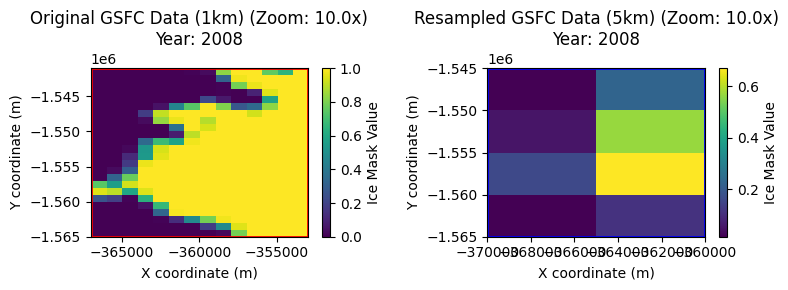

In [69]:
print("Lanczos3d Interpolation Results:")
plot_gsfc_comparison(2008, 5, new_gsfc=interpolation_results['lanczos3d'], zoom=10, original_gsfc=gsfc)

print("Nearest Interpolation Results:")
plot_gsfc_comparison(2008, 5, new_gsfc=interpolation_results['nearest'], zoom=10, original_gsfc=gsfc)

print("Linear Interpolation Results:")
plot_gsfc_comparison(2008, 5, new_gsfc=interpolation_results['linear'], zoom=10, original_gsfc=gsfc)

print("Cubic Interpolation Results:")
plot_gsfc_comparison(2008, 5, new_gsfc=interpolation_results['cubic'], zoom=10, original_gsfc=gsfc)
